# Bab 2: Data and Sampling Distributions

**Buku:** *Practical Statistics for Data Scientists* (O'Reilly)

## Ringkasan Bab
Walaupun sekarang eranya big data, sampling tetap penting. Bab ini menjelaskan hubungan antara sampel dan populasi, serta cara mengukur ketidakpastian dari suatu estimasi. Pokok bahasannya:

1. **Random sampling dan bias sampel.** Cara data dikumpulkan lebih menentukan daripada seberapa banyak datanya.
2. **Selection bias.** Data snooping, vast search effect, dan regression to the mean.
3. **Distribusi sampling dari sebuah statistik.** Central limit theorem dan standard error.
4. **Bootstrap.** Resampling untuk memperkirakan distribusi sampling tanpa rumus.
5. **Confidence interval.** Rentang nilai yang menggambarkan ketidakpastian estimasi.
6. **Distribusi-distribusi umum.** Normal, long-tailed, t Student, binomial, chi-square, F, Poisson, eksponensial, dan Weibull.

In [1]:
from pathlib import Path
import random
import numpy as np
import pandas as pd
from scipy import stats
import seaborn as sns
import matplotlib.pylab as plt
from sklearn.utils import resample

DATA = Path('..') / 'data'
sns.set_style('whitegrid')

## 1. Random Sampling dan Bias Sampel
**Penjelasan teori.**
- **Sampel** adalah bagian dari **populasi** yang lebih besar. Pada **random sampling**, setiap anggota populasi punya peluang yang sama untuk terpilih (*simple random sample*). Pengambilannya bisa **dengan** atau **tanpa pengembalian**.
- **Bias sampel** terjadi ketika sampel secara sistematis tidak mewakili populasi, misalnya survei yang hanya menelepon telepon rumah. Bias berbeda dengan error acak, karena bias tidak mengecil walaupun sampelnya diperbanyak.
- **Stratified sampling** membagi populasi ke dalam strata, lalu mengambil sampel acak dari tiap strata supaya semua kelompok terwakili.
- Kualitas lebih penting daripada kuantitas. Sampel acak kecil yang dirancang dengan baik lebih berguna daripada data raksasa yang pesertanya memilih sendiri. Contoh klasiknya adalah polling *Literary Digest* tahun 1936 dengan 2,4 juta respons yang meleset memprediksi pemenang pemilu karena sampelnya bias.

In [2]:
loans_income = pd.read_csv(DATA / 'loans_income.csv').squeeze('columns')
print(loans_income.describe())

count     50000.00000
mean      68760.51844
std       32872.03537
min        4000.00000
25%       45000.00000
50%       62000.00000
75%       85000.00000
max      199000.00000
Name: x, dtype: float64


## 2. Selection Bias
**Penjelasan teori.** Selection bias adalah bias yang muncul dari cara observasi dipilih. Bentuknya antara lain:
- **Data snooping atau vast search effect.** Kalau kita mencari pola atau mencoba model cukup banyak, pasti ada yang kelihatan signifikan hanya karena kebetulan. Cara menjaganya adalah memakai data *holdout* dan menganggap proses pencarian itu sebagai bagian dari prosedur.
- **Sampling tidak acak** dan **cherry-picking** data.
- **Regression to the mean.** Nilai yang ekstrem cenderung diikuti nilai yang lebih biasa karena sebagian dari hasil ekstrem itu murni keberuntungan. Ini bukan efek sebab-akibat.

## 3. Distribusi Sampling dari Sebuah Statistik
**Penjelasan teori.** **Distribusi sampling** adalah distribusi dari suatu statistik (misalnya mean atau median) yang dihitung dari banyak sampel berulang yang diambil dari populasi yang sama.

- **Central Limit Theorem (CLT).** Distribusi sampling dari mean cenderung mendekati **normal** ketika ukuran sampel membesar, walaupun populasinya sendiri tidak normal. Inilah dasar dari confidence interval dan uji yang berbasis distribusi normal.
- **Standard error (SE).** Simpangan baku dari distribusi sampling. Untuk mean, $SE=\dfrac{s}{\sqrt{n}}$. Kalau ukuran sampel dikali empat, SE menjadi setengahnya (aturan akar kuadrat).
- Jangan tertukar antara **simpangan baku** (sebaran data) dan **standard error** (sebaran estimasi).

In [3]:
np.random.seed(7)
# Data: individual values, means of 5, means of 20
sample_data = pd.DataFrame({
    'income': loans_income.sample(1000),
    'type': 'Data',
})
sample_mean_05 = pd.DataFrame({
    'income': [loans_income.sample(5).mean() for _ in range(1000)],
    'type': 'Mean of 5',
})
sample_mean_20 = pd.DataFrame({
    'income': [loans_income.sample(20).mean() for _ in range(1000)],
    'type': 'Mean of 20',
})
results = pd.concat([sample_data, sample_mean_05, sample_mean_20])
print(results.head())

        income  type
29430  22800.0  Data
27750  65000.0  Data
47782  58000.0  Data
10498  30000.0  Data
24747  42000.0  Data


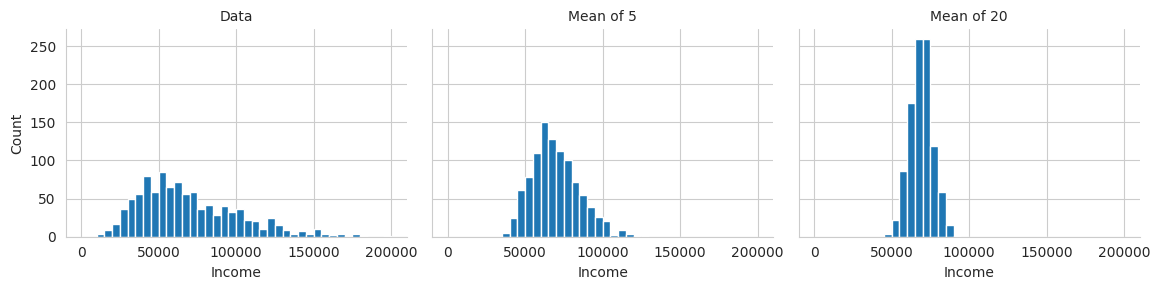

In [4]:
g = sns.FacetGrid(results, col='type', col_wrap=3, height=3, aspect=1.3)
g.map(plt.hist, 'income', range=[0, 200000], bins=40)
g.set_axis_labels('Income', 'Count')
g.set_titles('{col_name}')
plt.tight_layout(); plt.show()

Histogram untuk nilai tunggal terlihat miring. Semakin besar jumlah data yang dipakai untuk menghitung mean, distribusinya makin sempit dan makin mirip lonceng. Ini contoh CLT yang bekerja.

## 4. Bootstrap
**Penjelasan teori.** **Bootstrap** memperkirakan distribusi sampling dengan cara **resampling dengan pengembalian** dari sampel yang kita punya:

1. Ambil sampel berukuran $n$ *dengan pengembalian* dari data, lalu hitung statistiknya.
2. Ulangi sebanyak $R$ kali (misalnya 1000).
3. Pakai $R$ hasil itu untuk memperkirakan standard error, bias, atau confidence interval.

Idenya, kita membayangkan sampel yang ada digandakan berkali-kali untuk membentuk "populasi bayangan". Metode ini tidak butuh asumsi distribusi dan bisa dipakai untuk median, koefisien regresi, dan statistik lainnya. **Bagging** di Bab 6 dibangun dari ide ini. Perlu dibedakan juga dengan permutation test di Bab 3 yang resampling-nya *tanpa* pengembalian.

In [5]:
results = []
for nrepeat in range(1000):
    sample = resample(loans_income)
    results.append(sample.median())
results = pd.Series(results)
print('Bootstrap Statistics:')
print(f'original: {loans_income.median()}')
print(f'bias: {results.mean() - loans_income.median()}')
print(f'std. error: {results.std()}')

Bootstrap Statistics:
original: 62000.0
bias: -94.2300000000032
std. error: 249.20808026078785


## 5. Confidence Interval
**Penjelasan teori.** **Confidence interval (CI)** dengan tingkat kepercayaan $x\%$ adalah rentang yang, kalau prosedur pengambilan sampel diulang terus, akan memuat parameter sebenarnya sekitar $x\%$ dari waktu. Resep bootstrap-nya:

1. Ambil banyak resampel bootstrap dan hitung statistiknya.
2. Buang $[(100-x)/2]\%$ dari tiap ujung, sisanya adalah CI.

Interval yang lebih lebar berarti ketidakpastian lebih besar. Tingkat kepercayaan yang lebih tinggi (99% dibanding 90%) membuat interval lebih lebar, sedangkan $n$ yang lebih besar membuat interval lebih sempit. **Catatan penafsiran:** CI bukan berarti "peluang parameter ada di dalam interval ini adalah 90%". Parameter itu nilainya tetap, yang acak adalah intervalnya.

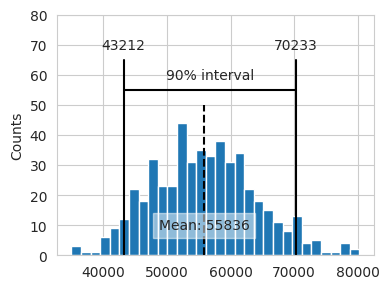

In [6]:
np.random.seed(3)
# create a sample of 20 loan income data
sample20 = resample(loans_income, n_samples=20, replace=False)

results = []
for nrepeat in range(500):
    sample = resample(sample20)
    results.append(sample.mean())
results = pd.Series(results)

confidence_interval = list(results.quantile([0.05, 0.95]))
ax = results.plot.hist(bins=30, figsize=(4, 3))
ax.plot(confidence_interval, [55, 55], color='black')
for x in confidence_interval:
    ax.plot([x, x], [0, 65], color='black')
    ax.text(x, 70, f'{x:.0f}', horizontalalignment='center', verticalalignment='center')
ax.text(sum(confidence_interval) / 2, 60, '90% interval',
        horizontalalignment='center', verticalalignment='center')
meanIncome = results.mean()
ax.plot([meanIncome, meanIncome], [0, 50], color='black', linestyle='--')
ax.text(meanIncome, 10, f'Mean: {meanIncome:.0f}',
        bbox=dict(facecolor='white', edgecolor='white', alpha=0.5),
        horizontalalignment='center', verticalalignment='center')
ax.set_ylim(0, 80); ax.set_ylabel('Counts')
plt.tight_layout(); plt.show()

In [7]:
np.random.seed(3)
sample20 = resample(loans_income, n_samples=20, replace=False)
sample20_mean = sample20.mean()
# Analytic (t-based) CI for comparison
ci = stats.t.interval(0.90, df=19, loc=sample20.mean(), scale=stats.sem(sample20))
print('Sample mean (n=20):', sample20_mean)
print('90% t-interval    :', ci)

Sample mean (n=20): 55734.1
90% t-interval    : (np.float64(41235.62704493809), np.float64(70232.5729550619))


## 6. Distribusi Normal
**Penjelasan teori.** **Distribusi normal (Gaussian)** berbentuk lonceng, simetris, dan sepenuhnya ditentukan oleh rata-rata $\mu$ dan simpangan baku $\sigma$. **Z-score** menstandarkan sebuah nilai: $z=\frac{x-\mu}{\sigma}$, artinya berapa simpangan baku nilai itu dari rata-rata. **Normal standar** punya $\mu=0$ dan $\sigma=1$. Sekitar 68%, 95%, dan 99,7% data berada dalam 1, 2, dan 3 simpangan baku dari rata-rata.

**QQ-plot** membandingkan kuantil sampel dengan kuantil normal teoretis. Kalau titik-titiknya mengikuti garis diagonal, datanya kira-kira normal. Data mentah sering kali *tidak* normal. Yang normal berkat CLT adalah **distribusi sampling dari mean**.

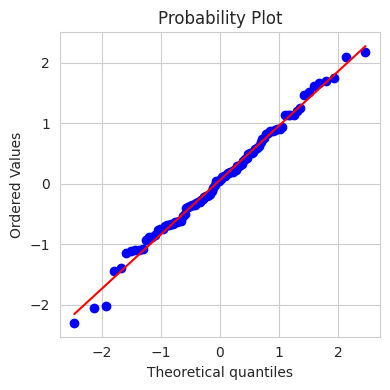

In [8]:
fig, ax = plt.subplots(figsize=(4, 4))
norm_sample = stats.norm.rvs(size=100, random_state=1)
stats.probplot(norm_sample, plot=ax)
plt.tight_layout(); plt.show()

## 7. Distribusi Long-Tailed
**Penjelasan teori.** Banyak variabel di dunia nyata punya **ekor** (nilai ekstrem) yang lebih tebal daripada distribusi normal, atau miring, atau punya outlier. Kalau kita memakai asumsi normal pada kasus seperti ini, peluang kejadian ekstrem (misalnya anjloknya harga saham) akan diremehkan. Pada QQ-plot, titik-titiknya akan melengkung menjauhi garis di kedua ujung.

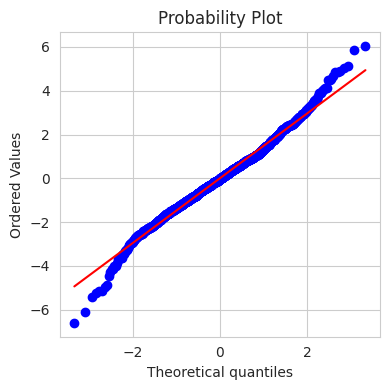

In [9]:
sp500_px = pd.read_csv(DATA / 'sp500_data.csv.gz', index_col=0)
nflx = sp500_px.NFLX
nflx = np.diff(np.log(nflx[nflx > 0]))

fig, ax = plt.subplots(figsize=(4, 4))
stats.probplot(nflx, plot=ax)
plt.tight_layout(); plt.show()

## 8. Distribusi t Student
**Penjelasan teori.** Bentuknya mirip normal tetapi **ekornya lebih tebal**, dan bentuknya bergantung pada **derajat bebas** ($n-1$ untuk mean sampel). Semakin besar $n$, distribusinya makin mendekati normal. Distribusi ini dipakai untuk confidence interval dan uji pada mean ketika simpangan baku populasi tidak diketahui, dengan statistik $t=\frac{\bar{x}-\mu_0}{s/\sqrt{n}}$.

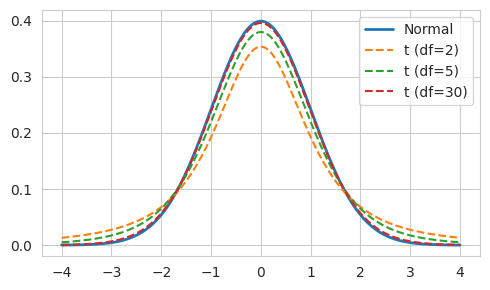

In [10]:
x = np.linspace(-4, 4, 200)
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(x, stats.norm.pdf(x), label='Normal', lw=2)
for df in (2, 5, 30):
    ax.plot(x, stats.t.pdf(x, df), label=f't (df={df})', ls='--')
ax.legend(); plt.tight_layout(); plt.show()

## 9. Distribusi Binomial
**Penjelasan teori.** Distribusi ini menghitung jumlah **sukses** dari $n$ **percobaan** independen, dengan peluang sukses $p$ di tiap percobaan (percobaan *Bernoulli*). Fungsi massa peluangnya $P(X=k)=\binom{n}{k}p^k(1-p)^{n-k}$, dengan rata-rata $np$ dan varians $np(1-p)$. Untuk $n$ yang besar (ketika $np$ dan $n(1-p)$ sama-sama lebih dari 10), binomial bisa didekati dengan distribusi normal.

In [11]:
print('P(X=2) , n=5,  p=0.1 :', stats.binom.pmf(2, n=5, p=0.1))
print('P(X<=2), n=5,  p=0.1 :', stats.binom.cdf(2, n=5, p=0.1))
print('P(X=0) , n=200, p=0.02:', stats.binom.pmf(0, n=200, p=0.02))

P(X=2) , n=5,  p=0.1 : 0.07289999999999992
P(X<=2), n=5,  p=0.1 : 0.99144
P(X=0) , n=200, p=0.02: 0.017587946605721567


## 10. Distribusi Chi-Square
**Penjelasan teori.** Statistik chi-square mengukur seberapa jauh frekuensi yang diamati menyimpang dari frekuensi yang diharapkan: $\chi^2=\sum\frac{(O-E)^2}{E}$. Distribusinya (dengan parameter derajat bebas) menjadi acuan untuk uji chi-square di Bab 3.

## 11. Distribusi F
**Penjelasan teori.** Distribusi F adalah rasio dua varians, misalnya variabilitas antar kelompok dibanding variabilitas dalam kelompok. Distribusi ini menjadi dasar **ANOVA** dan uji signifikansi regresi (Bab 3 dan 4), dan punya dua parameter derajat bebas.

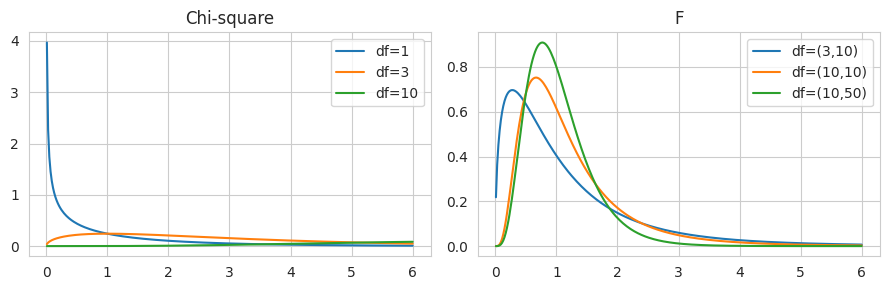

In [12]:
x = np.linspace(0.01, 6, 300)
fig, axes = plt.subplots(1, 2, figsize=(9, 3))
for df in (1, 3, 10):
    axes[0].plot(x, stats.chi2.pdf(x, df), label=f'df={df}')
axes[0].set_title('Chi-square'); axes[0].legend()
for d1, d2 in ((3, 10), (10, 10), (10, 50)):
    axes[1].plot(x, stats.f.pdf(x, d1, d2), label=f'df=({d1},{d2})')
axes[1].set_title('F'); axes[1].legend()
plt.tight_layout(); plt.show()

## 12. Distribusi Poisson dan yang Terkait
**Penjelasan teori.** Banyak proses menghasilkan **kejadian dengan laju rata-rata yang konstan** $\lambda$ per satuan waktu atau ruang.

- **Poisson.** Jumlah kejadian dalam satu interval tertentu. $P(X=k)=\frac{\lambda^k e^{-\lambda}}{k!}$, dengan rata-rata dan varians sama dengan $\lambda$.
- **Eksponensial.** Waktu (atau jarak) *di antara* dua kejadian dengan laju yang sama, $f(t)=\lambda e^{-\lambda t}$.
- **Weibull.** Kalau laju kejadian *berubah seiring waktu* (misalnya kerusakan karena aus), Weibull menggeneralisasi eksponensial lewat parameter bentuk $\beta$ ($\beta>1$ berarti laju kerusakan naik, $\beta<1$ turun, $\beta=1$ sama dengan eksponensial) dan parameter skala $\eta$.

In [13]:
print('Poisson samples (lambda=2):', stats.poisson.rvs(2, size=100, random_state=1)[:15])
print('Exponential samples (rate=0.2):', stats.expon.rvs(scale=1/0.2, size=100, random_state=1)[:5])
print('Weibull samples (shape=1.5, scale=5000):',
      stats.weibull_min.rvs(1.5, scale=5000, size=100, random_state=1)[:5])

Poisson samples (lambda=2): [2 1 0 1 2 2 0 3 3 3 0 2 4 2 4]
Exponential samples (rate=0.2): [2.69802919e+00 6.37062627e+00 5.71906793e-04 1.80006377e+00
 7.93547976e-01]
Weibull samples (shape=1.5, scale=5000): [3314.01469915 5876.40094596   11.78166957 2530.35776144 1465.67875777]


/usr/local/lib/python3.12/dist-packages/scipy/stats/_continuous_distns.py:2750: RuntimeWarning: divide by zero encountered in power
  return c*pow(x, c-1)*np.exp(-pow(x, c))


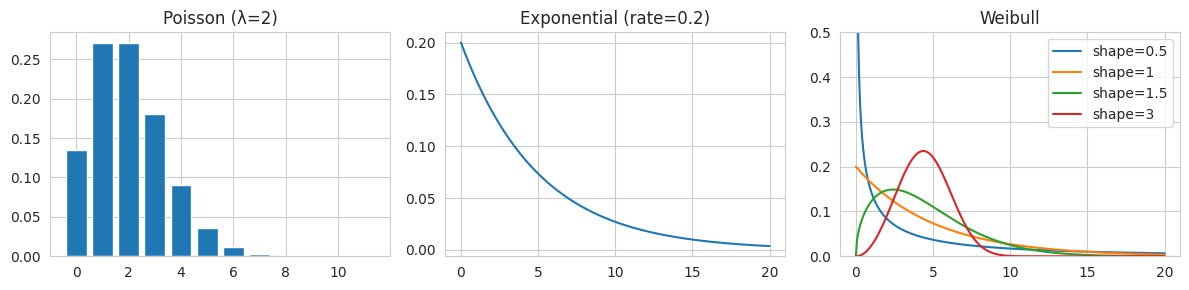

In [14]:
x = np.linspace(0, 20, 300)
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
k = np.arange(0, 12)
axes[0].bar(k, stats.poisson.pmf(k, 2)); axes[0].set_title('Poisson (λ=2)')
axes[1].plot(x, stats.expon.pdf(x, scale=1/0.2)); axes[1].set_title('Exponential (rate=0.2)')
for shape in (0.5, 1, 1.5, 3):
    axes[2].plot(x, stats.weibull_min.pdf(x, shape, scale=5), label=f'shape={shape}')
axes[2].set_ylim(0, 0.5); axes[2].set_title('Weibull'); axes[2].legend()
plt.tight_layout(); plt.show()

## Poin Penting
- Random sampling melindungi dari bias. Data besar yang tidak representatif bisa lebih buruk daripada sampel acak yang kecil.
- **CLT** membuat mean sampel bisa dianggap mendekati normal, dan **SE** $=s/\sqrt{n}$.
- **Bootstrap** memberi standard error dan confidence interval untuk hampir semua statistik lewat resampling dengan pengembalian.
- Kenali distribusinya: normal, t, binomial, chi-square, F, Poisson, eksponensial, dan Weibull. Masing-masing cocok untuk jenis proses pembangkit data tertentu.